In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = [10,8]
plt.rcParams['figure.max_open_warning'] = 50
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import imblearn

C:\Users\User\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
data = pd.read_csv("malgenome215dataset1260malware2539benign.csv")

In [3]:
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,S
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,S
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,S
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,0,1,1,1,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3795,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3796,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,B
3797,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B


In [4]:
Class = data["class"]

In [5]:
Class

0       S
1       S
2       S
3       S
4       S
       ..
3794    B
3795    B
3796    B
3797    B
3798    B
Name: class, Length: 3799, dtype: object

In [6]:
data = data.drop("class", axis=1).copy()
data["Class"] = Class

In [7]:
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,Class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,S
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,S
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,S
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,0,1,1,1,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3795,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3796,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,B
3797,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B


In [8]:
data.shape

(3799, 216)

In [9]:
ls = ["S","B"]

In [10]:
for i in ls:
    if(i == "B"):
        data.Class[data.Class == i] = 0
    else:
        data.Class[data.Class == i] = 1

<ipython-input-10-1108f5149ec3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Class[data.Class == i] = 1
<ipython-input-10-1108f5149ec3>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.Class[data.Class == i] = 0


In [11]:
data.Class

0       1
1       1
2       1
3       1
4       1
       ..
3794    0
3795    0
3796    0
3797    0
3798    0
Name: Class, Length: 3799, dtype: object

In [12]:
Counter(data.Class)

Counter({1: 1260, 0: 2539})

In [13]:
classes = []
counts=[]
for i in range(0,2):
    classes.append(i)
    x = data['Class'].value_counts()[i]
    counts.append(x)
print(counts)
dataframe = pd.DataFrame(classes,counts)
print(classes)

[2539, 1260]
[0, 1]


In [25]:
dataframe = pd.DataFrame({'Class':["benign", "malware"],'Counts': [2539, 1260]})

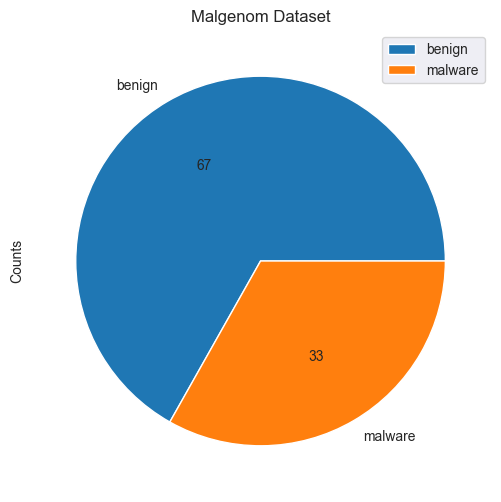

In [29]:
dataframe.groupby(['Class']).sum().plot(kind='pie', y='Counts', figsize=(6,6), autopct='%1.0f', title="Malgenom Dataset")
plt.savefig("Malgenom-pie-pic")
plt.show()

In [87]:
data.Class = data['Class'].astype(np.int64)

In [88]:
data.Class

0       1
1       1
2       1
3       1
4       1
       ..
3794    0
3795    0
3796    0
3797    0
3798    0
Name: Class, Length: 3799, dtype: int64

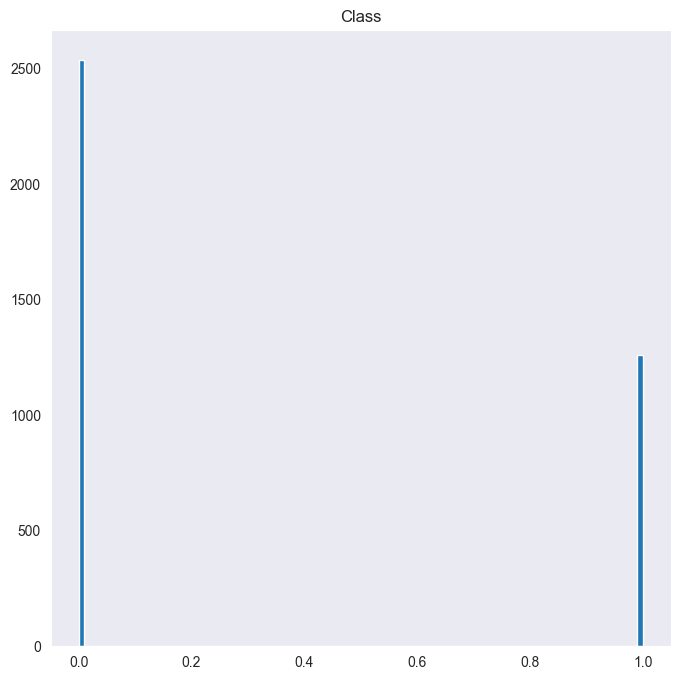

In [89]:
data.hist(column='Class',figsize=(8,8), bins=100, grid = False, zorder=2, rwidth=0.9)
plt.show()

# 2-OverSampling using SMOTE

In [90]:
import imblearn
print(imblearn.__version__)

0.10.1


In [91]:
y = data.Class.copy()
x = data.drop("Class", axis=1).copy()

In [92]:
x

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,0,1,1,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3795,1,1,1,1,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3796,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3797,1,1,1,1,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [93]:
y

0       1
1       1
2       1
3       1
4       1
       ..
3794    0
3795    0
3796    0
3797    0
3798    0
Name: Class, Length: 3799, dtype: int64

In [94]:
counter = Counter(y)
for k,v in counter.items():
     per = v / len(y) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=1260 (33.167%)
Class=0, n=2539 (66.833%)


In [95]:
Counter(data.Class)

Counter({1: 1260, 0: 2539})

In [96]:
counter

Counter({1: 1260, 0: 2539})

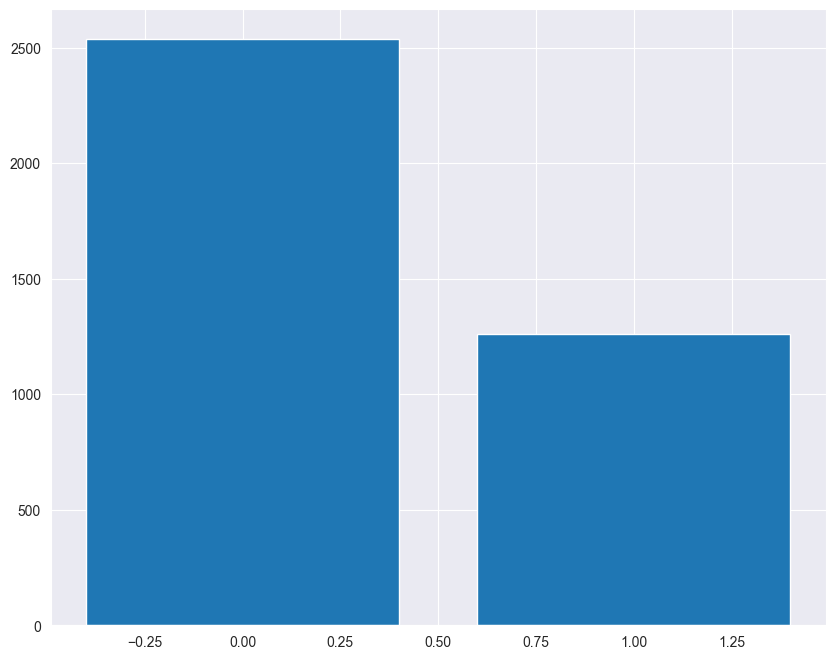

In [97]:
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

In [98]:
from imblearn.over_sampling import SMOTE

In [99]:
overSample = SMOTE()
x,y = overSample.fit_resample(x,y)
OverSampleCounter = Counter(y)

In [100]:
for k,v in OverSampleCounter.items():
     per = v / len(y) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=2539 (50.000%)
Class=0, n=2539 (50.000%)


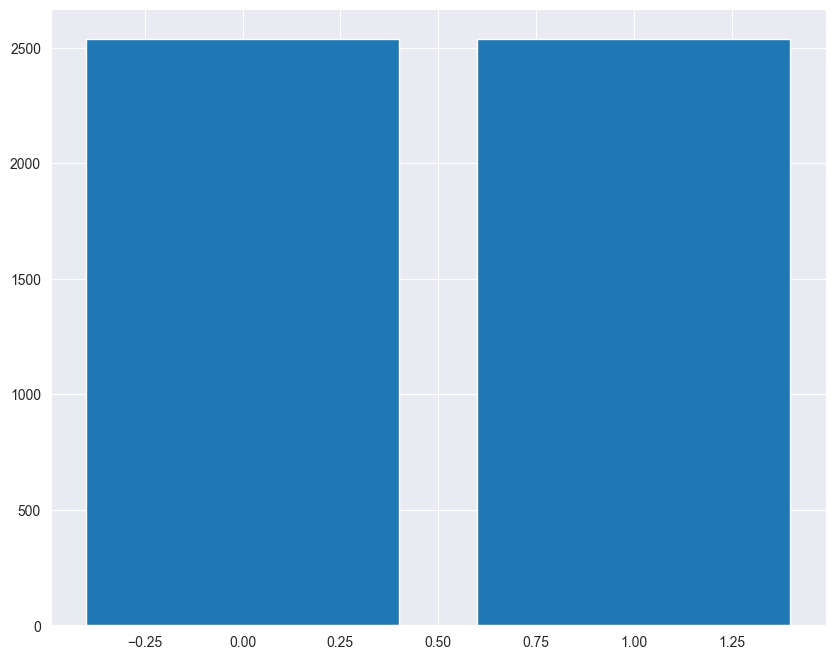

In [101]:
pyplot.bar(counter.keys(), OverSampleCounter.values())
pyplot.show()

In [102]:
x

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
5074,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5075,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5076,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,1,0,0,0,0


In [103]:
y

0       1
1       1
2       1
3       1
4       1
       ..
5073    1
5074    1
5075    1
5076    1
5077    1
Name: Class, Length: 5078, dtype: int64

In [104]:
y.unique()

array([1, 0], dtype=int64)

# 3-Outlier Handling

In [105]:
features = data.drop("Class", axis=1).copy()
classes = data.Class.copy()

In [106]:
features

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,0,1,1,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3795,1,1,1,1,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3796,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3797,1,1,1,1,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [107]:
classes

0       1
1       1
2       1
3       1
4       1
       ..
3794    0
3795    0
3796    0
3797    0
3798    0
Name: Class, Length: 3799, dtype: int64

In [108]:
Counter(classes)

Counter({1: 1260, 0: 2539})

In [109]:
overSample = SMOTE()
features,classes = overSample.fit_resample(features,classes)
OverSampleCounter = Counter(classes)

In [110]:
counter = Counter(classes)
for k,v in OverSampleCounter.items():
     per = v / len(classes) * 100
     print('Class=%d, n=%d (%.3f%%)' % (k, v, per))

Class=1, n=2539 (50.000%)
Class=0, n=2539 (50.000%)


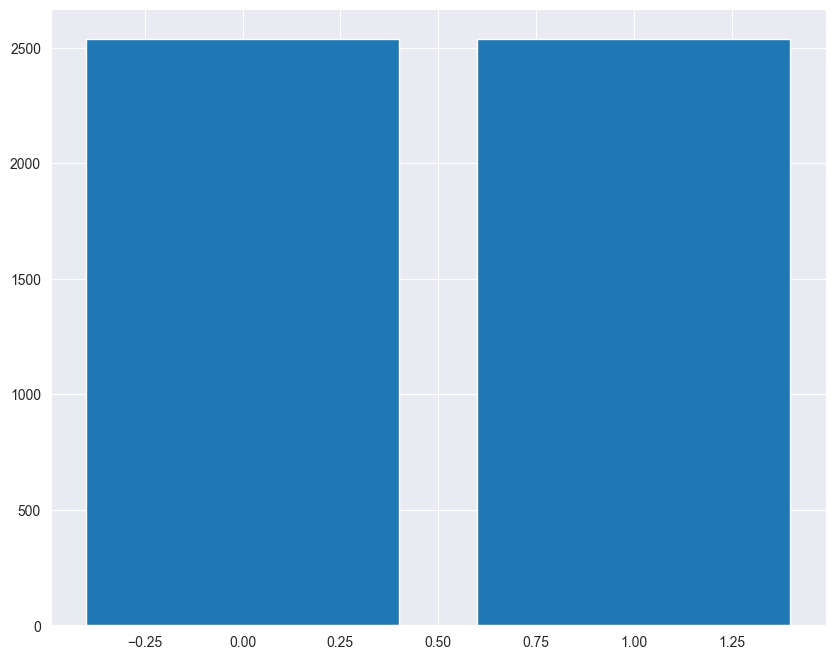

In [111]:
pyplot.bar(counter.keys(), OverSampleCounter.values())
pyplot.show()

In [112]:
features

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
5074,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,1,0,0,0,0
5075,0,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
5076,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0


In [113]:
classes

0       1
1       1
2       1
3       1
4       1
       ..
5073    1
5074    1
5075    1
5076    1
5077    1
Name: Class, Length: 5078, dtype: int64

In [114]:
features_outlier_handler = features.copy()

for column in features :
    Q1 = features[column].quantile(0.25)
    Q3 = features[column].quantile(0.75)
    print(Q1,Q3)
    IQR = Q3-Q1
    print(IQR)
    lowerLimit = Q1 - (1.5 * IQR)
    upperLimit = Q3 + (1.5 * IQR)
    print(lowerLimit, upperLimit)
    features_outlier_handler[column] = np.where(features[column] > upperLimit, upperLimit,
                                  np.where(features[column] < lowerLimit, lowerLimit,
                                  features[column]))
    print("###############################################################")
    #boxplot = features.boxplot(grid=True, fontsize=10, column=column, figsize=(10,8))
    #features.hist(column=column, bins=200, alpha = 1, grid=False, figsize=(20,20), color='#86bf91', zorder=2, rwidth=0.9, sharex=True, xlabelsize=20, ylabelsize=20)

0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 1.0
1.0
-1.5 2.5
#############################################

###############################################################
1.0 1.0
0.0
1.0 1.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 1.0
1.0
-1.5 2.5
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0
0.0 0.0
###############################################################
0.0 0.0
0.0

In [115]:
for column in features_outlier_handler:
    print("columnName: ", column)
    print("columnContents: ",features_outlier_handler[column].values)

columnName:  transact
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  bindService
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  onServiceConnected
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  ServiceConnection
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  android.os.Binder
columnContents:  [0. 0. 0. ... 1. 0. 0.]
columnName:  READ_SMS
columnContents:  [0. 1. 0. ... 0. 1. 1.]
columnName:  attachInterface
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  WRITE_SMS
columnContents:  [0. 0. 0. ... 0. 1. 1.]
columnName:  TelephonyManager.getSubscriberId
columnContents:  [0. 1. 0. ... 1. 1. 1.]
columnName:  Ljava.lang.Class.getCanonicalName
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  Ljava.lang.Class.getMethods
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  android.intent.action.BOOT_COMPLETED
columnContents:  [1. 1. 0. ... 0. 1. 0.]
columnName:  Ljava.lang.Class.getField
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  READ_PHONE_STATE

columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  DexClassLoader
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  WRITE_CALENDAR
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  PROCESS_OUTGOING_CALLS
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  BIND_DEVICE_ADMIN
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  CHANGE_WIFI_MULTICAST_STATE
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  MASTER_CLEAR
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  android.intent.action.PACKAGE_DATA_CLEARED
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  FLASHLIGHT
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  android.intent.action.BATTERY_LOW
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  SET_ALARM
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  RECEIVE_MMS
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  divideMessage
columnContents:  [0. 0. 0. ... 0. 0. 0.]
columnName:  WRITE_CALL_LOG
columnContents:  [0. 0. 0. ... 0. 0. 0.]
column

In [116]:
features

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
5074,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,1,0,0,0,0
5075,0,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
5076,0,0,0,0,0,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0


In [117]:
features_outlier_handler

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5074,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5075,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5076,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


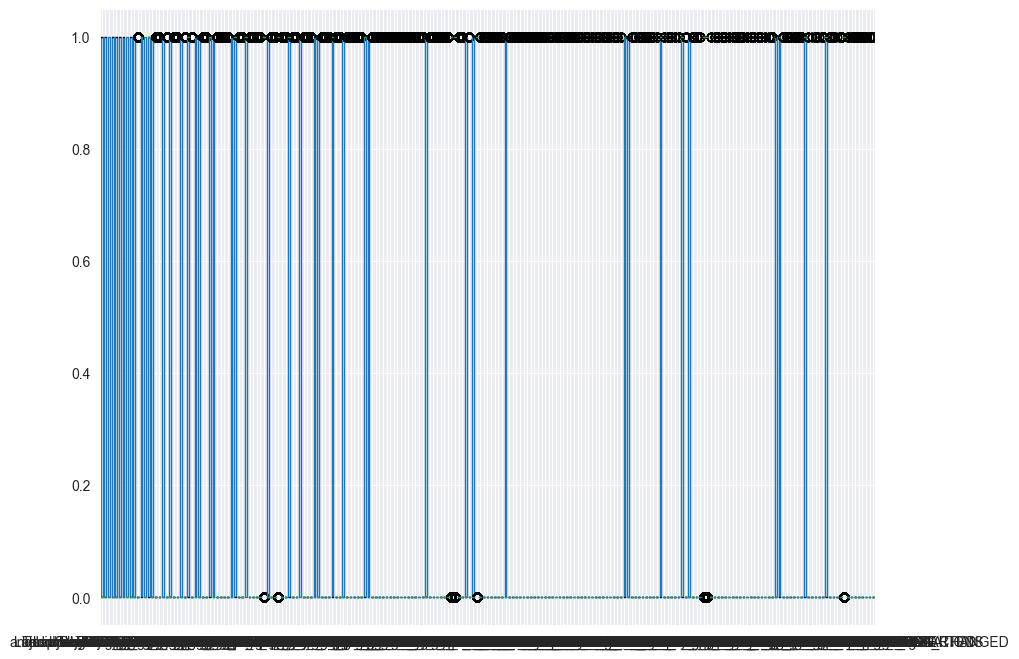

In [118]:
boxplot = features.boxplot(grid=True, fontsize=10, figsize=(10,8))
plt.show()

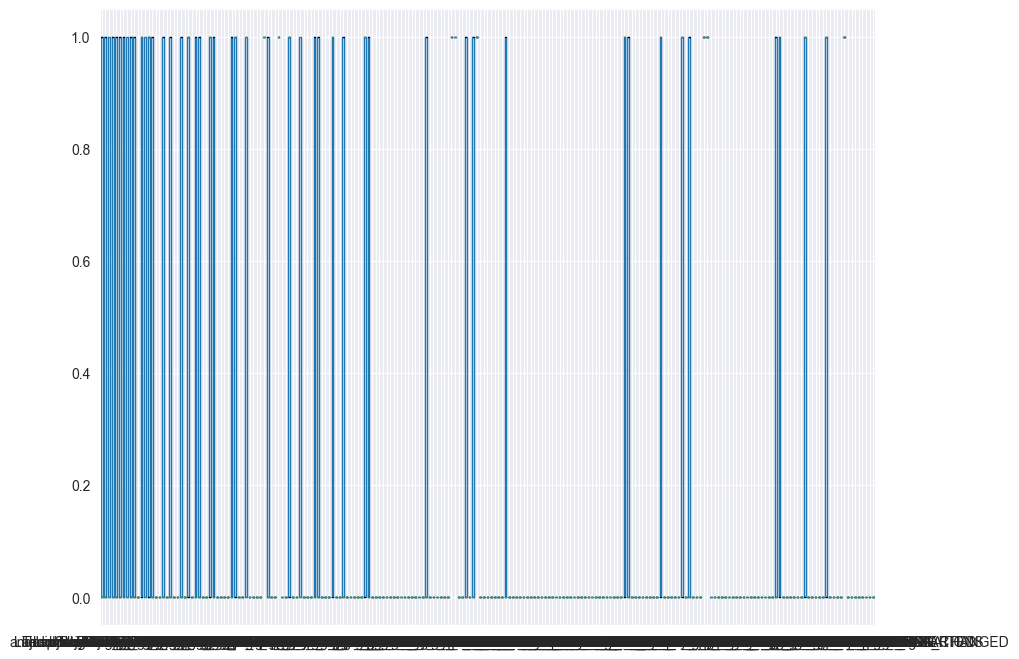

In [119]:
boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, figsize=(10,8))
plt.show()

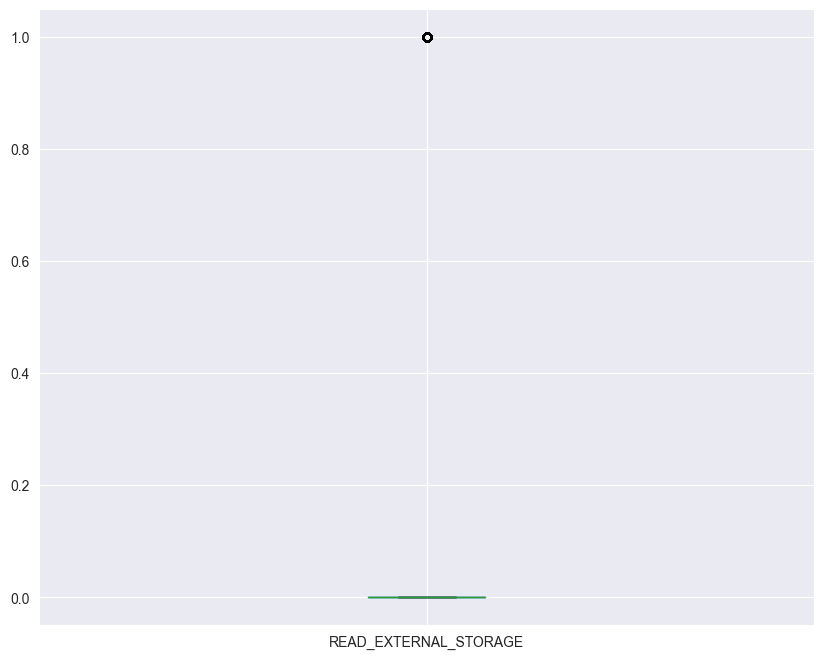

In [120]:
boxplot = features.boxplot(grid=True, fontsize=10, column="READ_EXTERNAL_STORAGE", figsize=(10,8))
plt.show()

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
plt.figure(figsize=(10,8))
sns.kdeplot(features.READ_EXTERNAL_STORAGE, shade=True, color='green')
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.kdeplot(features_outlier_handler.READ_EXTERNAL_STORAGE, shade=True, color='green')
plt.show()

In [ ]:
boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, column="ACCESS_CACHE_FILESYSTEM", figsize=(10,8))
plt.show()

In [ ]:
boxplot = features.boxplot(grid=True, fontsize=10, column="ACCESS_CACHE_FILESYSTEM", figsize=(10,8))
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.kdeplot(features.ACCESS_CACHE_FILESYSTEM, shade=True, color='green')
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.kdeplot(features_outlier_handler.ACCESS_CACHE_FILESYSTEM, shade=True, color='green')
plt.show()

In [ ]:
for colName in features_outlier_handler:
    boxplot = features_outlier_handler.boxplot(grid=True, fontsize=10, column= colName, figsize=(10,8))
plt.show()

# 4-Normalization(Scalling)

# 4.1-MinMax Scalling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
norm = MinMaxScaler()
features_outlier_handler_norm = norm.fit_transform(features_outlier_handler)

In [ ]:
features_outlier_handler_norm

In [ ]:
features_outlier_handler_norm = pd.DataFrame(features_outlier_handler_norm, columns=features_outlier_handler.columns)

In [ ]:
features_outlier_handler_norm

In [ ]:
features_outlier_handler_norm.describe()

In [ ]:
features_outlier_handler_norm.shape

In [ ]:
features_outlier_handler_norm.info()

In [ ]:
boxplot = features_outlier_handler_norm.boxplot(grid=True, fontsize=10, figsize=(10,8))
plt.show()

In [ ]:
for colName in features_outlier_handler_norm:
    boxplot = features_outlier_handler_norm.boxplot(grid=True, fontsize=10, column= colName, figsize=(10,8))
plt.show()

In [ ]:
classes

In [ ]:
features_outlier_handler_norm

In [ ]:
features_outlier_handler_norm["Class"] = classes

In [ ]:
features_outlier_handler_norm

In [ ]:
Counter(features_outlier_handler_norm.Class)

# creating a csv from the resulting data

In [122]:
features["Class"] = classes

In [124]:
features_outlier_handler

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,READ_EXTERNAL_STORAGE,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5074,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5075,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5076,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [123]:
features

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,Class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
5074,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,1,0,0,0,0,1
5075,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
5076,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
features.to_csv("features_outlier_handler_norm_two_classes_only.csv", index=False)